In [1]:
import os
import json
import time
from typing import Sequence, Tuple
import numpy as np
import jax
import jax.numpy as jnp
import optax
from flax.training.train_state import TrainState as BaseTrainState
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
import distrax
import orbax.checkpoint as ocp
import wandb
from jaxued.environments.underspecified_env import EnvParams, EnvState, Observation, UnderspecifiedEnv
from jaxued.linen import ResetRNN
from jaxued.environments import Maze, MazeRenderer
from jaxued.environments.maze import Level, make_level_generator
from jaxued.utils import max_mc, positive_value_loss
from jaxued.wrappers import AutoResetWrapper
import chex

import logging
import hydra
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt

In [2]:
from omegaconf import OmegaConf
from hydra import initialize, compose


def load_hydra_config(config_path, config_name):
    # Initialize the Hydra context
    with initialize(config_path=config_path):
        # Compose the configuration
        cfg = compose(config_name=config_name)
        return cfg
    
config_path = "config"  # path to the directory containing the config file
config_name = "main_dr"  # name of the config file without the extension

config = load_hydra_config(config_path, config_name)

if config["num_env_steps"] is not None:
    config["num_updates"] = config["num_env_steps"] // (config["num_train_envs"] * config["num_steps"])

if config['mode'] == 'eval':
    os.environ['WANDB_MODE'] = 'disabled'

/tmp/ipykernel_440550/1688720957.py:7: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=config_path):


In [3]:
class TrainState(BaseTrainState):
    update_count: int
    last_obs: chex.ArrayTree
    last_env_state: chex.ArrayTree

# region PPO helper functions
def compute_gae(
    gamma: float,
    lambd: float,
    last_value: chex.Array,
    values: chex.Array,
    rewards: chex.Array,
    dones: chex.Array,
) -> Tuple[chex.Array, chex.Array]:
    """This takes in arrays of shape (NUM_STEPS, NUM_ENVS) and returns the advantages and targets.

    Args:
        gamma (float): 
        lambd (float): 
        last_value (chex.Array):  Shape (NUM_ENVS)
        values (chex.Array): Shape (NUM_STEPS, NUM_ENVS)
        rewards (chex.Array): Shape (NUM_STEPS, NUM_ENVS)
        dones (chex.Array): Shape (NUM_STEPS, NUM_ENVS)

    Returns:
        Tuple[chex.Array, chex.Array]: advantages, targets; each of shape (NUM_STEPS, NUM_ENVS)
    """
    def compute_gae_at_timestep(carry, x):
        gae, next_value = carry
        value, reward, done = x
        delta = reward + gamma * next_value * (1 - done) - value
        gae = delta + gamma * lambd * (1 - done) * gae
        return (gae, value), gae

    _, advantages = jax.lax.scan(
        compute_gae_at_timestep,
        (jnp.zeros_like(last_value), last_value),
        (values, rewards, dones),
        reverse=True,
        unroll=16,
    )
    return advantages, advantages + values

def sample_trajectories_rnn(
    rng: chex.PRNGKey,
    env: UnderspecifiedEnv,
    env_params: EnvParams,
    train_state: TrainState,
    init_obs: Observation,
    init_env_state: EnvState,
    num_envs: int,
    max_episode_length: int,
) -> Tuple[Tuple[chex.PRNGKey, TrainState, chex.ArrayTree, Observation, EnvState, chex.Array], Tuple[Observation, chex.Array, chex.Array, chex.Array, chex.Array, chex.Array, dict]]:
    """This samples trajectories from the environment using the agent specified by the `train_state`.

    Args:

        rng (chex.PRNGKey): Singleton 
        env (UnderspecifiedEnv): 
        env_params (EnvParams): 
        train_state (TrainState): Singleton
        init_obs (Observation): The initial observation, shape (NUM_ENVS, ...)
        init_env_state (EnvState): The initial env state (NUM_ENVS, ...)
        num_envs (int): The number of envs that are vmapped over.
        max_episode_length (int): The maximum episode length, i.e., the number of steps to do the rollouts for.

    Returns:
        Tuple[Tuple[chex.PRNGKey, TrainState, chex.ArrayTree, Observation, EnvState, chex.Array], Tuple[Observation, chex.Array, chex.Array, chex.Array, chex.Array, chex.Array, dict]]: (rng, train_state, last_obs, last_env_state, last_value), traj, where traj is (obs, action, reward, done, log_prob, value, info). The first element in the tuple consists of arrays that have shapes (NUM_ENVS, ...) (except `rng` and and `train_state` which are singleton). The second element in the tuple is of shape (NUM_STEPS, NUM_ENVS, ...), and it contains the trajectory.
    """
    def sample_step(carry, _):
        rng, train_state, obs, env_state, last_done = carry
        rng, rng_action, rng_step = jax.random.split(rng, 3)

        x = jax.tree_map(lambda x: x[None, ...], obs)
        pi, value = train_state.apply_fn(train_state.params, x)
        action = pi.sample(seed=rng_action)
        log_prob = pi.log_prob(action)
        value, action, log_prob = (
            value.squeeze(0),
            action.squeeze(0),
            log_prob.squeeze(0),
        )

        next_obs, env_state, reward, done, info = jax.vmap(
            env.step, in_axes=(0, 0, 0, None)
        )(jax.random.split(rng_step, num_envs), env_state, action, env_params)

        carry = (rng, train_state, next_obs, env_state, done)
        return carry, (obs, action, reward, done, log_prob, value, info)

    (rng, train_state, last_obs, last_env_state, last_done), traj = jax.lax.scan(
        sample_step,
        (
            rng,
            train_state,
            init_obs,
            init_env_state,
            jnp.zeros(num_envs, dtype=bool),
        ),
        None,
        length=max_episode_length,
    )

    x = jax.tree_map(lambda x: x[None, ...], last_obs)
    _, last_value = train_state.apply_fn(train_state.params, x)

    return (rng, train_state, last_obs, last_env_state, last_value.squeeze(0)), traj


class ActorCritic(nn.Module):
    """This is an actor critic class that uses an LSTM
    """
    action_dim: Sequence[int]
    
    @nn.compact
    def __call__(self, inputs):
        obs = inputs
        
        img_embed = nn.Conv(16, kernel_size=(3, 3), strides=(1, 1), padding="VALID")(obs.image)
        img_embed = img_embed.reshape(*img_embed.shape[:-3], -1)
        img_embed = nn.relu(img_embed)
        
        dir_embed = jax.nn.one_hot(obs.agent_dir, 4)
        dir_embed = nn.Dense(5, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0), name="scalar_embed")(dir_embed)
        
        embedding = jnp.append(img_embed, dir_embed, axis=-1)

        actor_mean = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="actor0")(embedding)
        actor_mean = nn.relu(actor_mean)
        actor_mean = nn.Dense(self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0), name="actor1")(actor_mean)
        pi = distrax.Categorical(logits=actor_mean)

        critic = nn.Dense(32, kernel_init=orthogonal(2), bias_init=constant(0.0), name="critic0")(embedding)
        critic = nn.relu(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0), name="critic1")(critic)

        return pi, jnp.squeeze(critic, axis=-1)

In [4]:
# Setup the environment
env = Maze(max_height=13, max_width=13, agent_view_size=config["agent_view_size"], normalize_obs=True, fully_obs=True)
eval_env = env
sample_random_level = make_level_generator(env.max_height, env.max_width, config["n_walls"])
env_renderer = MazeRenderer(env, tile_size=8)
env = AutoResetWrapper(env, sample_random_level)
env_params = env.default_params

rng = jax.random.PRNGKey(14532)
rng, _rng = jax.random.split(rng)

In [7]:
def create_train_state(rng) -> TrainState:
    # Creates the train state
    def linear_schedule(count):
        frac = (
            1.0
            - (count // (config["num_minibatches"] * config["epoch_ppo"]))
            / config["num_updates"]
        )
        return config["lr"] * frac
    obs, _ = env.reset_to_level(rng, sample_random_level(rng), env_params)
    obs = jax.tree_map(
        lambda x: jnp.repeat(jnp.repeat(x[None, ...], config["num_train_envs"], axis=0)[None, ...], 256, axis=0),
        obs,
    )
    init_x = obs
    network = ActorCritic(env.action_space(env_params).n)
    rng, _rng = jax.random.split(rng)
    network_params = network.init(_rng, init_x)
    tx = optax.chain(
        optax.clip_by_global_norm(config["max_grad_norm"]),
        optax.adam(learning_rate=linear_schedule, eps=1e-5),
        # optax.adam(learning_rate=config["lr"], eps=1e-5),
    )

    rng_levels, rng_reset = jax.random.split(rng)
    new_levels = jax.vmap(sample_random_level)(jax.random.split(rng_levels, config["num_train_envs"]))
    init_obs, init_env_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng_reset, config["num_train_envs"]), new_levels, env_params)
    
    return TrainState.create(
        apply_fn=network.apply,
        params=network_params,
        tx=tx,
        update_count=0,
        last_obs=init_obs,
        last_env_state=init_env_state,
    )

In [8]:
rng, _rng = jax.random.split(rng)
train_state = create_train_state(_rng)

In [9]:
def update_actor_critic_rnn(
    rng: chex.PRNGKey,
    train_state: TrainState,
    batch: chex.ArrayTree,
    num_envs: int,
    n_steps: int,
    n_minibatch: int,
    n_epochs: int,
    clip_eps: float,
    entropy_coeff: float,
    critic_coeff: float,
    update_grad: bool=True,
) -> Tuple[Tuple[chex.PRNGKey, TrainState], chex.ArrayTree]:
    """This function takes in a rollout, and PPO hyperparameters, and updates the train state.

    Args:
        rng (chex.PRNGKey): 
        train_state (TrainState): 
        batch (chex.ArrayTree): obs, actions, dones, log_probs, values, targets, advantages
        num_envs (int): 
        n_steps (int): 
        n_minibatch (int): 
        n_epochs (int): 
        clip_eps (float): 
        entropy_coeff (float): 
        critic_coeff (float): 
        update_grad (bool, optional): If False, the train state does not actually get updated. Defaults to True.

    Returns:
        Tuple[Tuple[chex.PRNGKey, TrainState], chex.ArrayTree]: It returns a new rng, the updated train_state, and the losses. The losses have structure (loss, (l_vf, l_clip, entropy))
    """
    obs, actions, dones, log_probs, values, targets, advantages = batch
    last_dones = jnp.roll(dones, 1, axis=0).at[0].set(False)
    batch = obs, actions, last_dones, log_probs, values, targets, advantages
    
    def update_epoch(carry, _):
        def update_minibatch(train_state, minibatch):
            obs, actions, last_dones, log_probs, values, targets, advantages = minibatch
            
            def loss_fn(params):
                pi, values_pred = train_state.apply_fn(params, obs)
                log_probs_pred = pi.log_prob(actions)
                entropy = pi.entropy().mean()

                ratio = jnp.exp(log_probs_pred - log_probs)
                A = (advantages - advantages.mean()) / (advantages.std() + 1e-5)
                l_clip = (-jnp.minimum(ratio * A, jnp.clip(ratio, 1 - clip_eps, 1 + clip_eps) * A)).mean()

                values_pred_clipped = values + (values_pred - values).clip(-clip_eps, clip_eps)
                l_vf = 0.5 * jnp.maximum((values_pred - targets) ** 2, (values_pred_clipped - targets) ** 2).mean()

                loss = l_clip + critic_coeff * l_vf - entropy_coeff * entropy

                return loss, (l_vf, l_clip, entropy)

            grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
            loss, grads = grad_fn(train_state.params)
            if update_grad:
                train_state = train_state.apply_gradients(grads=grads)
            return train_state, loss

        rng, train_state = carry
        rng, rng_perm = jax.random.split(rng)
        permutation = jax.random.permutation(rng_perm, num_envs)
        minibatches = (
            *jax.tree_map(
                lambda x: jnp.take(x, permutation, axis=1)
                .reshape(x.shape[0], n_minibatch, -1, *x.shape[2:])
                .swapaxes(0, 1),
                batch,
            ),
        )
        train_state, losses = jax.lax.scan(update_minibatch, train_state, minibatches)
        return (rng, train_state), losses

    return jax.lax.scan(update_epoch, (rng, train_state), None, n_epochs)

In [10]:
rng, rng_replay = jax.random.split(rng)

(
    (rng, train_state, last_obs, last_env_state, last_value),
    (obs, actions, rewards, dones, log_probs, values, info),
) = sample_trajectories_rnn(
    rng,
    env,
    env_params,
    train_state,
    train_state.last_obs,
    train_state.last_env_state,
    config["num_train_envs"],
    config["num_steps"],
)
advantages, targets = compute_gae(config["gamma"], config["gae_lambda"], last_value, values, rewards, dones)

In [13]:
(rng, train_state), losses = update_actor_critic_rnn(
    rng,
    train_state,
    (obs, actions, dones, log_probs, values, targets, advantages),
    config["num_train_envs"],
    config["num_steps"],
    config["num_minibatches"],
    config["epoch_ppo"],
    config["clip_eps"],
    config["entropy_coeff"],
    config["critic_coeff"],
    update_grad=True,
)

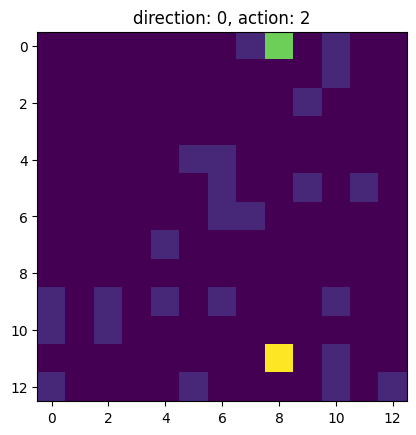

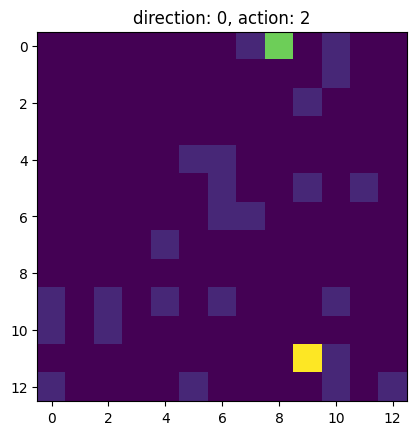

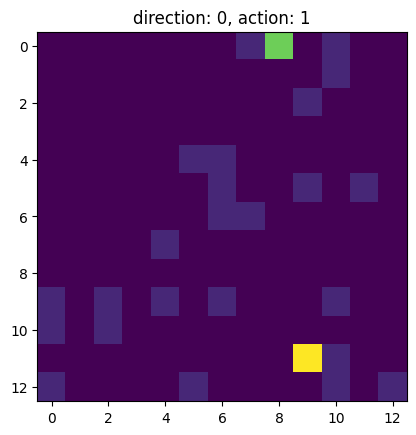

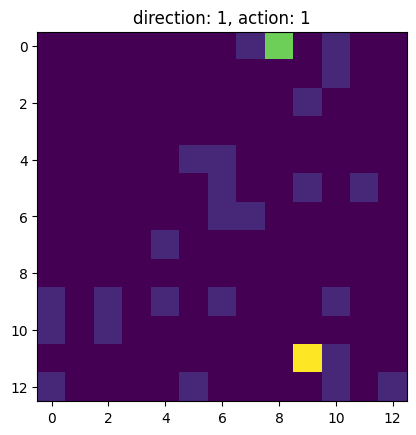

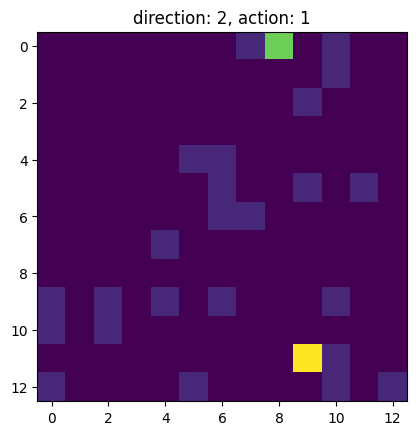

In [10]:
env_number = 1

for i in range(5):
    plt.imshow(obs.image[i, env_number][:, :, 0])
    plt.title(f"direction: {obs.agent_dir[i, env_number]}, action: {actions[i, env_number]}")
    plt.show()

# Env Testing

In [36]:
rng, rng_level, rng_reset = jax.random.split(rng, 3)
obs, env_state = env.reset_to_level(rng_reset, sample_random_level(rng_level), env_params)

In [39]:
rng, _rng = jax.random.split(rng)
next_obs, env_state, reward, done, _ = env.step(_rng, env_state, 2, env_params)

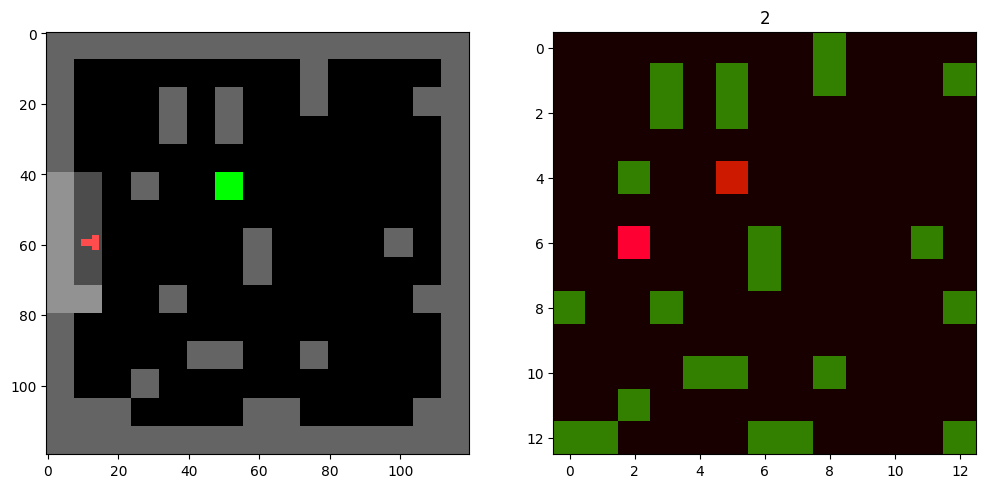

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

env_image = env_renderer.render_state(env_state.env_state, env_params)
ax1.imshow(env_image)

ax2.imshow(obs.image)
ax2.set_title(f"{obs.agent_dir}");